# DeliveryETA — Modélisation Prédictive des Temps de Livraison

## Objectif du projet

L'objectif de ce projet est de développer un modèle de Machine Learning capable de prédire le temps total de livraison d'une commande en minutes.

Cette prédiction peut aider une entreprise de livraison à :
- fournir une estimation du délai au client ;
- mieux planifier les livraisons ;
- améliorer l'affectation des livreurs ;
- identifier les facteurs qui influencent le temps de livraison.

## Variable cible

La variable que nous voulons prédire est :

`Delivery_Time_min`

Elle représente le temps total de livraison en minutes.

## Données utilisées

Le dataset contient des informations concernant :
- la distance de livraison ;
- les conditions météorologiques ;
- le niveau de trafic ;
- le moment de la journée ;
- le type de véhicule ;
- le temps de préparation ;
- l'expérience du livreur.

In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

## 2. Chargement du dataset

Nous chargeons le fichier CSV contenant les données de livraison à l'aide de Pandas.

In [ ]:
df = pd.read_csv("../data/delivery_dataset.csv")

## 3. Compréhension initiale des données

Avant de commencer le nettoyage, nous allons examiner la structure, les dimensions, les types de données, les valeurs manquantes et les doublons du dataset.

In [ ]:
print(df.head())

In [ ]:
print(df.shape)

In [11]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 91.3 KB
None


In [12]:
print(df.isnull().sum())

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [14]:
print(df.duplicated().sum())

0


In [ ]:
print(df.describe())

In [ ]:
# last 5 rows
print(df.tail())

     Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
995       107         8.50   Clear          High     Evening          Car   
996       271        16.28   Rainy           Low     Morning      Scooter   
997       861        15.62   Snowy          High     Evening      Scooter   
998       436        14.17   Clear           Low   Afternoon         Bike   
999       103         6.63   Foggy           Low       Night      Scooter   

     Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
995                    13                     3.0                 54  
996                     8                     9.0                 71  
997                    26                     2.0                 81  
998                     8                     0.0                 55  
999                    24                     3.0                 58  


In [24]:
# categoriees 
print(df["Weather"].value_counts())
print("-------------")
print(df["Traffic_Level"].value_counts())
print("-------------")
print(df["Time_of_Day"].value_counts())
print("-------------")
print(df["Vehicle_Type"].value_counts())


Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64
-------------
Traffic_Level
Medium    390
Low       383
High      197
Name: count, dtype: int64
-------------
Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64
-------------
Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64


Cleaning Data


In [75]:
clean_df = df.copy()
print(clean_df.isnull().sum())
clean_df["Weather"] = clean_df["Weather"].fillna(clean_df["Weather"].mode()[0])

clean_df["Traffic_Level"] = clean_df["Traffic_Level"].fillna(clean_df["Traffic_Level"].mode()[0])
clean_df["Vehicle_Type"] = clean_df["Vehicle_Type"].fillna(clean_df["Vehicle_Type"].mode()[0])
clean_df["Time_of_Day"] = clean_df["Time_of_Day"].fillna(clean_df["Time_of_Day"].mode()[0])
clean_df["Courier_Experience_yrs"] = clean_df["Courier_Experience_yrs"].fillna(clean_df["Courier_Experience_yrs"].median())

print(clean_df.isnull().sum())
#print(clean_df["Traffic_Level"].value_counts())



Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64
Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


Check Types

In [46]:
print(clean_df.dtypes)

Order_ID                    int64
Distance_km               float64
Weather                       str
Traffic_Level                 str
Time_of_Day                   str
Vehicle_Type                  str
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object


In [76]:
clean_df[
    [
        "Distance_km",
        "Preparation_Time_min",
        "Courier_Experience_yrs",
        "Delivery_Time_min"
    ]
].describe()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.059970,16.982000,4.592000,56.732000
std,5.696656,7.204553,2.871198,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,5.000000,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


### 4.4 Détection des valeurs aberrantes

Nous examinons les variables numériques afin d'identifier les valeurs potentiellement aberrantes. Une valeur aberrante n'est pas nécessairement une erreur : elle doit être analysée avant de décider de la conserver ou de la supprimer.

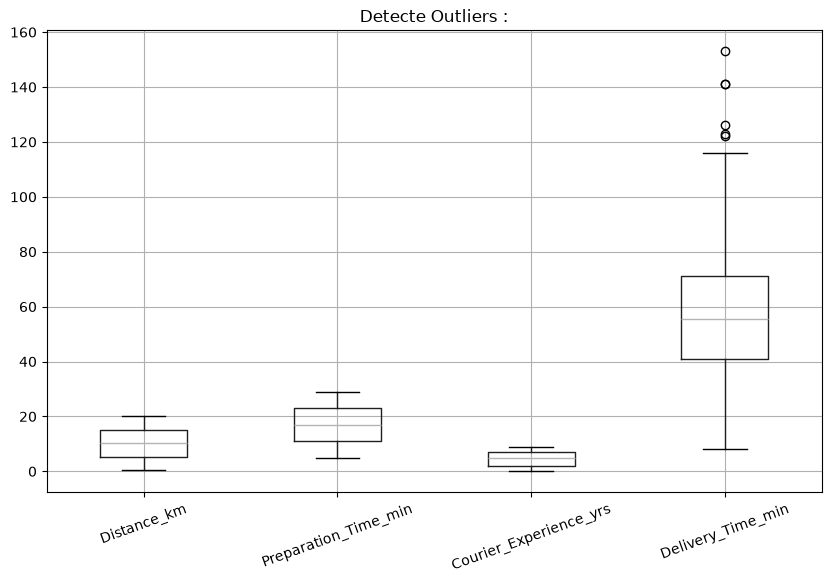

In [77]:
numerical_cols = [
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs",
    "Delivery_Time_min"
]

clean_df[numerical_cols].boxplot(figsize=(10, 6))
plt.title("Detecte Outliers :")
plt.xticks(rotation=20)
plt.show()

In [78]:
print(clean_df["Delivery_Time_min"].describe())

Q1 = clean_df["Delivery_Time_min"].quantile(0.25)
Q3 = clean_df["Delivery_Time_min"].quantile(0.75)

IQR = Q3 - Q1
print(f"IQR : {IQR}")
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"loweer bounf : {lower_bound}")
print(f"upper bound : {upper_bound}")

delivery_outliers = clean_df[
    (clean_df["Delivery_Time_min"] < lower_bound) |
    (clean_df["Delivery_Time_min"] > upper_bound)
]

print("Numbeeeer of outliersss:", len(delivery_outliers))

count    1000.000000
mean       56.732000
std        22.070915
min         8.000000
25%        41.000000
50%        55.500000
75%        71.000000
max       153.000000
Name: Delivery_Time_min, dtype: float64
IQR : 30.0
loweer bounf : -4.0
upper bound : 116.0
Numbeeeer of outliersss: 6


In [ ]:
#clean_df = clean_df[
#    (clean_df["Delivery_Time_min"] >= lower_bound) &
#    (clean_df["Delivery_Time_min"] <= upper_bound)
#]

#print(clean_df.describe())

          Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
count   994.000000   994.000000            994.000000              994.000000   
mean    500.085513    10.016308             16.959759                4.595573   
std     289.113713     5.684717              7.206240                2.876340   
min       1.000000     0.590000              5.000000                0.000000   
25%     249.250000     5.015000             11.000000                2.000000   
50%     501.500000    10.150000             17.000000                5.000000   
75%     749.750000    14.890000             23.000000                7.000000   
max    1000.000000    19.990000             29.000000                9.000000   

       Delivery_Time_min  
count         994.000000  
mean           56.263581  
std            21.276034  
min             8.000000  
25%            41.000000  
50%            55.000000  
75%            71.000000  
max           116.000000  
